# Assignment 3 — KAN 2.0 / MultKAN Experiments

This notebook implements the KAN 2.0 component of the project: evaluating whether MultKAN improves equation recovery on selected Feynman symbolic regression equations.

The aim is to compare KAN 2.0 against:
1. MLP baseline
2. Standard KAN
3. KAN 2.0 / MultKAN

The evaluation focuses on prediction accuracy, training stability, noise robustness, and symbolic recovery.

## 2. Setup

This section installs and imports the required packages. PyKAN is used for the KAN 2.0 / MultKAN implementation.

In [ ]:
!pip install pykan -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 5.3 MB/s eta 0:00:00


In [ ]:
import os
import time
import traceback
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from kan import *

## 3. Reproducibility and device setup

This section fixes random seeds and selects GPU if available.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEEDS = [0, 1, 2, 3, 4]

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Device: cpu


## 4. Dataset loading

The Feynman data files and metadata are loaded here. Each selected equation has predefined train, validation, and test splits.

In [ ]:
!wget "https://drive.google.com/uc?export=download&id=12X6DEdfMB99GPJpWAgORZrlEuuc5uIEk" -O "dataA3.zip"
!unzip -o -q dataA3.zip

--2026-05-27 04:41:49--  https://drive.google.com/uc?export=download&id=12X6DEdfMB99GPJpWAgORZrlEuuc5uIEk
Resolving drive.google.com (drive.google.com)... 74.125.128.100, 74.125.128.113, 74.125.128.101, ...
Connecting to drive.google.com (drive.google.com)|74.125.128.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=12X6DEdfMB99GPJpWAgORZrlEuuc5uIEk&export=download [following]
--2026-05-27 04:41:50--  https://drive.usercontent.google.com/download?id=12X6DEdfMB99GPJpWAgORZrlEuuc5uIEk&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.31.132, 2a00:1450:4013:c1a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.31.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12845323 (12M) [application/octet-stream]
Saving to: ‘dataA3.zip’

dataA3.zip          100%[===================>]  12.25M  --.-KB/s    

In [ ]:
metadata = pd.read_csv("Assign3/data/selected_equations_metadata.csv", index_col="safe_name")
metadata

,equation,formula,difficulty,n_variables,variables,lows,highs,n_train,n_val,n_test
safe_name,,,,,,,,,,
I_6_2,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),easy,2,"sigma, theta","1.0, 1.0","3.0, 3.0",10000,2000,2000
I_14_3,I.14.3,m*g*z,easy,3,"m, g, z","1.0, 1.0, 1.0","5.0, 5.0, 5.0",10000,2000,2000
I_18_4,I.18.4,(m1*r1+m2*r2)/(m1+m2),medium,4,"m1, m2, r1, r2","1.0, 1.0, 1.0, 1.0","5.0, 5.0, 5.0, 5.0",10000,2000,2000
I_29_16,I.29.16,sqrt(x1**2+x2**2-2*x1*x2*cos(theta1-theta2)),medium,4,"x1, x2, theta1, theta2","1.0, 1.0, 1.0, 1.0","5.0, 5.0, 5.0, 5.0",10000,2000,2000
I_9_18,I.9.18,G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2),hard,9,"m1, m2, G, x1, x2, y1, y2, z1, z2","1.0, 1.0, 1.0, 3.0, 1.0, 3.0, 1.0, 3.0, 1.0","2.0, 2.0, 2.0, 4.0, 2.0, 4.0, 2.0, 4.0, 2.0",10000,2000,2000


## 5. Selected equation summary

This section checks the five selected Feynman equations used in the project. The selected set should include easy, medium, and hard equations so that MLP, KAN, and KAN 2.0 are tested across increasing symbolic complexity.

In [ ]:
SELECTED_EQUATIONS = [
    "I_6_2",
    "I_14_3",
    "I_18_4",
    "I_29_16",
    "I_9_18"
]

SELECTED_EQUATIONS

['I_6_2', 'I_14_3', 'I_18_4', 'I_29_16', 'I_9_18']

In [ ]:
selected_metadata = metadata.loc[SELECTED_EQUATIONS]

selected_metadata[
    ["equation", "formula", "difficulty", "n_variables", "n_train", "n_val", "n_test"]
]

,equation,formula,difficulty,n_variables,n_train,n_val,n_test
safe_name,,,,,,,
I_6_2,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),easy,2,10000,2000,2000
I_14_3,I.14.3,m*g*z,easy,3,10000,2000,2000
I_18_4,I.18.4,(m1*r1+m2*r2)/(m1+m2),medium,4,10000,2000,2000
I_29_16,I.29.16,sqrt(x1**2+x2**2-2*x1*x2*cos(theta1-theta2)),medium,4,10000,2000,2000
I_9_18,I.9.18,G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2),hard,9,10000,2000,2000


## 6. Helper functions

The following helper functions load one equation dataset, scale the input and target values, convert the data into PyKAN format, build a KAN 2.0 / MultKAN model, and evaluate model performance.

The noisy training files are already generated, so this notebook loads the correct training file for each noise level rather than adding noise manually.

In [ ]:
DATA_DIR = "Assign3/data"

for eq in SELECTED_EQUATIONS:
    eq_path = os.path.join(DATA_DIR, eq)
    print(eq, "exists:", os.path.exists(eq_path))
    if os.path.exists(eq_path):
        print("  files:", os.listdir(eq_path))

I_6_2 exists: True
  files: ['train_noise_0p1.csv', 'train_noise_0p0.csv', 'train_noise_0p01.csv', 'train_clean.csv', 'val_clean.csv', 'train_noise_0p05.csv', 'test_clean.csv']
I_14_3 exists: True
  files: ['train_noise_0p1.csv', 'train_noise_0p0.csv', 'train_noise_0p01.csv', 'train_clean.csv', 'val_clean.csv', 'train_noise_0p05.csv', 'test_clean.csv']
I_18_4 exists: True
  files: ['train_noise_0p1.csv', 'train_noise_0p0.csv', 'train_noise_0p01.csv', 'train_clean.csv', 'val_clean.csv', 'train_noise_0p05.csv', 'test_clean.csv']
I_29_16 exists: True
  files: ['train_noise_0p1.csv', 'train_noise_0p0.csv', 'train_noise_0p01.csv', 'train_clean.csv', 'val_clean.csv', 'train_noise_0p05.csv', 'test_clean.csv']
I_9_18 exists: True
  files: ['train_noise_0p1.csv', 'train_noise_0p0.csv', 'train_noise_0p01.csv', 'train_clean.csv', 'val_clean.csv', 'train_noise_0p05.csv', 'test_clean.csv']


In [ ]:
def load_equation_data(equation_name, noise_sigma=0.0, data_dir=DATA_DIR):
    """
    Load train, validation, and test data for one selected Feynman equation.

    The training set may be clean or noisy depending on noise_sigma.
    Validation and test sets are always clean.
    """

    noise_map = {
        0.0: "train_noise_0p0.csv",
        0.01: "train_noise_0p01.csv",
        0.05: "train_noise_0p05.csv",
        0.1: "train_noise_0p1.csv",
    }

    if noise_sigma not in noise_map:
        raise ValueError(f"noise_sigma must be one of {list(noise_map.keys())}")

    eq_dir = os.path.join(data_dir, equation_name)

    train_path = os.path.join(eq_dir, noise_map[noise_sigma])
    val_path = os.path.join(eq_dir, "val_clean.csv")
    test_path = os.path.join(eq_dir, "test_clean.csv")

    if not os.path.exists(train_path):
        raise FileNotFoundError(f"Missing training file: {train_path}")
    if not os.path.exists(val_path):
        raise FileNotFoundError(f"Missing validation file: {val_path}")
    if not os.path.exists(test_path):
        raise FileNotFoundError(f"Missing test file: {test_path}")

    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    x_cols = [c for c in train_df.columns if c != "y"]

    X_train = train_df[x_cols].values
    y_train = train_df["y"].values.reshape(-1, 1)

    X_val = val_df[x_cols].values
    y_val = val_df["y"].values.reshape(-1, 1)

    X_test = test_df[x_cols].values
    y_test = test_df["y"].values.reshape(-1, 1)

    return X_train, y_train, X_val, y_val, X_test, y_test, x_cols

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test, x_cols = load_equation_data(
    equation_name="I_6_2",
    noise_sigma=0.0
)

print("Input columns:", x_cols)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Input columns: ['sigma', 'theta']
X_train: (10000, 2)
y_train: (10000, 1)
X_val: (2000, 2)
y_val: (2000, 1)
X_test: (2000, 2)
y_test: (2000, 1)


In [ ]:
for eq in SELECTED_EQUATIONS:
    X_train, y_train, X_val, y_val, X_test, y_test, x_cols = load_equation_data(eq, noise_sigma=0.0)
    print(f"{eq}: variables={len(x_cols)}, train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

I_6_2: variables=2, train=(10000, 2), val=(2000, 2), test=(2000, 2)
I_14_3: variables=3, train=(10000, 3), val=(2000, 3), test=(2000, 3)
I_18_4: variables=4, train=(10000, 4), val=(2000, 4), test=(2000, 4)
I_29_16: variables=4, train=(10000, 4), val=(2000, 4), test=(2000, 4)
I_9_18: variables=9, train=(10000, 9), val=(2000, 9), test=(2000, 9)


In [ ]:
def scale_data(X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Standardise inputs and targets using only the training data statistics.

    Validation and test data are transformed using scalers fitted only on
    the training data to avoid data leakage.
    """

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_s = x_scaler.fit_transform(X_train)
    X_val_s = x_scaler.transform(X_val)
    X_test_s = x_scaler.transform(X_test)

    y_train_s = y_scaler.fit_transform(y_train)
    y_val_s = y_scaler.transform(y_val)
    y_test_s = y_scaler.transform(y_test)

    return X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s, x_scaler, y_scaler

In [ ]:
X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s, x_scaler, y_scaler = scale_data(
    X_train, y_train, X_val, y_val, X_test, y_test
)

print("Scaled X_train mean:", np.round(X_train_s.mean(axis=0), 4))
print("Scaled X_train std:", np.round(X_train_s.std(axis=0), 4))
print("Scaled y_train mean:", np.round(y_train_s.mean(), 4))
print("Scaled y_train std:", np.round(y_train_s.std(), 4))

Scaled X_train mean: [-0.  0.  0. -0.  0. -0. -0.  0.  0.]
Scaled X_train std: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Scaled y_train mean: 0.0
Scaled y_train std: 1.0


In [ ]:
def make_kan_dataset(X_train, y_train, X_val, y_val):
    """
    Convert NumPy arrays into the dictionary format expected by PyKAN.

    PyKAN uses the keys 'test_input' and 'test_label' internally during fitting.
    In this notebook, those correspond to the validation set, not the final test set.
    """

    dataset = {
        "train_input": torch.tensor(X_train, dtype=torch.float32, device=device),
        "train_label": torch.tensor(y_train, dtype=torch.float32, device=device),
        "test_input": torch.tensor(X_val, dtype=torch.float32, device=device),
        "test_label": torch.tensor(y_val, dtype=torch.float32, device=device),
    }

    return dataset

In [ ]:
def build_multkan_model(n_vars, add_width=2, mul_width=2, grid=3, k=3, seed=0):
    """
    Build a KAN 2.0 / MultKAN-style model.

    The width structure is:
        [[n_vars, 0], [add_width, mul_width], [1, 0]]

    This gives the hidden layer:
    - add_width additive nodes
    - mul_width multiplication nodes

    Multiplication nodes are important because many Feynman equations contain
    products, powers, and inverse-square interactions.
    """

    set_seed(seed)

    model = KAN(
        width=[[n_vars, 0], [add_width, mul_width], [1, 0]],
        grid=grid,
        k=k,
        seed=seed,
        device=device
    )

    return model

In [ ]:
def count_parameters(model):
    """
    Count trainable parameters in a PyTorch/PyKAN model.
    """

    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
def evaluate_model(model, X_test_s, y_test_s, y_scaler):
    """
    Evaluate the trained model on the clean test set.

    Returns:
    - scaled test MSE
    - original-scale RMSE
    - original-scale R²
    """

    model.eval()

    X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32, device=device)

    with torch.no_grad():
        y_pred_s = model(X_test_tensor).detach().cpu().numpy()

    mse_scaled = mean_squared_error(y_test_s, y_pred_s)

    y_pred_original = y_scaler.inverse_transform(y_pred_s)
    y_test_original = y_scaler.inverse_transform(y_test_s)

    rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    r2_original = r2_score(y_test_original, y_pred_original)

    return mse_scaled, rmse_original, r2_original

In [ ]:
# Build one small MultKAN model to check that the architecture works
test_model = build_multkan_model(
    n_vars=X_train_s.shape[1],
    add_width=2,
    mul_width=2,
    grid=3,
    k=3,
    seed=0
)

print(test_model)
print("Trainable parameters:", count_parameters(test_model))

checkpoint directory created: ./model
saving model version 0.0
MultKAN(
  (act_fun): ModuleList(
    (0-1): 2 x KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
  (symbolic_fun): ModuleList(
    (0-1): 2 x Symbolic_KANLayer()
  )
)
Trainable parameters: 696


## 7. Single-run KAN 2.0 training function

This function trains one KAN 2.0 / MultKAN model for one equation, one seed, and one noise level.

It returns the metrics required for the final comparison table:
- scaled test MSE
- original-scale RMSE
- original-scale R²
- parameter count
- training time
- divergence status

In [ ]:
def train_kan2_single_run(
    equation_name,
    seed=0,
    grid=3,
    k=3,
    add_width=2,
    mul_width=2,
    noise_sigma=0.0,
    adam_steps=20,
    lbfgs_steps=10,
    lamb=0.001,
    do_prune=False
):
    """
    Train one KAN 2.0 / MultKAN model on one selected Feynman equation.

    Parameters
    ----------
    equation_name : str
        Safe equation name, e.g. 'I_6_2'.
    seed : int
        Random seed for reproducibility.
    grid : int
        KAN grid size.
    k : int
        Spline order.
    add_width : int
        Number of additive hidden nodes.
    mul_width : int
        Number of multiplicative hidden nodes.
    noise_sigma : float
        Training-target noise level. Must match available noisy training files:
        0.0, 0.01, 0.05, or 0.1.
    adam_steps : int
        Number of Adam optimisation steps.
    lbfgs_steps : int
        Number of LBFGS fine-tuning steps.
    lamb : float
        Sparsity regularisation strength used by PyKAN.
    do_prune : bool
        Whether to attempt model pruning. Kept False by default because pruning
        can fail depending on PyKAN save/state behaviour.

    Returns
    -------
    result : dict
        Dictionary containing performance metrics and run metadata.
    """

    start_time = time.time()

    result = {
        "equation": equation_name,
        "method": "KAN2_MultKAN",
        "seed": seed,
        "grid": grid,
        "k": k,
        "add_width": add_width,
        "mul_width": mul_width,
        "noise_sigma": noise_sigma,
        "test_mse_scaled": np.nan,
        "rmse_original": np.nan,
        "r2_original": np.nan,
        "params": np.nan,
        "training_time_sec": np.nan,
        "diverged": True,
        "error_message": ""
    }

    try:
        # Reproducibility
        set_seed(seed)

        # 1. Load clean or noisy training data
        X_train, y_train, X_val, y_val, X_test, y_test, x_cols = load_equation_data(
            equation_name=equation_name,
            noise_sigma=noise_sigma
        )

        # 2. Scale inputs and outputs using training statistics only
        X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s, x_scaler, y_scaler = scale_data(
            X_train, y_train, X_val, y_val, X_test, y_test
        )

        # 3. Convert train/validation split into PyKAN dataset format
        dataset = make_kan_dataset(
            X_train=X_train_s,
            y_train=y_train_s,
            X_val=X_val_s,
            y_val=y_val_s
        )

        # 4. Build KAN 2.0 / MultKAN model
        model = build_multkan_model(
            n_vars=X_train_s.shape[1],
            add_width=add_width,
            mul_width=mul_width,
            grid=grid,
            k=k,
            seed=seed
        )

        result["params"] = count_parameters(model)

        # 5. Stage 1 training: Adam
        model.fit(
            dataset,
            opt="Adam",
            steps=adam_steps,
            lamb=lamb
        )

        # 6. Optional pruning
        if do_prune:
            try:
                model = model.prune()
                result["params_after_prune"] = count_parameters(model)
            except Exception as prune_error:
                result["error_message"] += (
                    f"Pruning failed: {repr(prune_error)}. "
                    "Continued without pruning. "
                )

        # 7. Stage 2 training: LBFGS fine-tuning
        model.fit(
            dataset,
            opt="LBFGS",
            steps=lbfgs_steps,
            lamb=lamb
        )

        # 8. Final evaluation on clean test set
        test_mse_scaled, rmse_original, r2_original = evaluate_model(
            model=model,
            X_test_s=X_test_s,
            y_test_s=y_test_s,
            y_scaler=y_scaler
        )

        result["test_mse_scaled"] = test_mse_scaled
        result["rmse_original"] = rmse_original
        result["r2_original"] = r2_original
        result["diverged"] = not np.isfinite(test_mse_scaled)

    except Exception as e:
        result["error_message"] = repr(e)
        result["traceback"] = traceback.format_exc()

    result["training_time_sec"] = time.time() - start_time

    return result

In [ ]:
# Quick check that the function exists
print(train_kan2_single_run)

<function train_kan2_single_run at 0x783070248e00>


## 8. Smoke test

Before running the full experiment, a short smoke test is performed on one easy equation using very few training steps. This checks whether the KAN 2.0 / MultKAN pipeline runs end-to-end.

The goal is not high accuracy yet. The goal is simply to confirm that:
- the data loads correctly,
- the model trains,
- the model evaluates on the clean test set,
- the returned metrics are finite.

In [ ]:
smoke_result = train_kan2_single_run(
    equation_name="I_6_2",
    seed=0,
    grid=3,
    k=3,
    add_width=2,
    mul_width=2,
    noise_sigma=0.0,
    adam_steps=5,
    lbfgs_steps=2,
    lamb=0.001,
    do_prune=False
)

smoke_result

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.26e+00 | test_loss: 2.33e+00 | reg: 2.05e+01 | : 100%|█| 5/5 [00:02<00:00,  1.93it/s


saving model version 0.1


| train_loss: 6.85e-02 | test_loss: 6.66e-02 | reg: 1.84e+01 | : 100%|█| 2/2 [00:04<00:00,  2.20s/it

saving model version 0.2


{'equation': 'I_6_2',
 'method': 'KAN2_MultKAN',
 'seed': 0,
 'grid': 3,
 'k': 3,
 'add_width': 2,
 'mul_width': 2,
 'noise_sigma': 0.0,
 'test_mse_scaled': 0.004362361046731687,
 'rmse_original': np.float64(0.002816275337645594),
 'r2_original': 0.9956503436214253,
 'params': 192,
 'training_time_sec': 7.025464296340942,
 'diverged': False,
 'error_message': ''}

## 9. Clean-data stability experiment

This section trains KAN 2.0 / MultKAN on the clean training data for all five selected Feynman equations.

Each equation is trained using five random seeds. The purpose is to evaluate:
- clean-data prediction accuracy,
- training stability across seeds,
- parameter count,
- training time,
- divergence rate.

In [ ]:
clean_results = []

for equation_name in SELECTED_EQUATIONS:
    for seed in SEEDS:
        print(f"Running equation={equation_name}, seed={seed}")

        res = train_kan2_single_run(
            equation_name=equation_name,
            seed=seed,
            grid=3,
            k=3,
            add_width=2,
            mul_width=2,
            noise_sigma=0.0,
            adam_steps=20,
            lbfgs_steps=10,
            lamb=0.001,
            do_prune=False
        )

        clean_results.append(res)

        # Save after every run so progress is not lost if the notebook crashes
        pd.DataFrame(clean_results).to_csv("kan2_clean_results.csv", index=False)

        print({
            "equation": res["equation"],
            "seed": res["seed"],
            "test_mse_scaled": res["test_mse_scaled"],
            "r2_original": res["r2_original"],
            "diverged": res["diverged"],
            "time": res["training_time_sec"],
            "error": res["error_message"]
        })

clean_df = pd.DataFrame(clean_results)
clean_df

Running equation=I_6_2, seed=0
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.92e+00 | test_loss: 5.84e+00 | reg: 7.38e+01 | : 100%|█| 20/20 [00:02<00:00,  8.30it


saving model version 0.1


| train_loss: 5.75e-02 | test_loss: 5.79e-02 | reg: 2.46e+01 | : 100%|█| 10/10 [00:18<00:00,  1.87s/


saving model version 0.2
{'equation': 'I_6_2', 'seed': 0, 'test_mse_scaled': 0.0034753719236769354, 'r2_original': 0.9965347496744615, 'diverged': False, 'time': 21.189907789230347, 'error': ''}
Running equation=I_6_2, seed=1
checkpoint directory created: ./model
saving model version 0.0


...

| train_loss: 1.67e+00 | test_loss: 1.32e+00 | reg: 1.44e+02 | : 100%|█| 20/20 [00:02<00:00,  6.77it


saving model version 0.1


| train_loss: 1.03e-01 | test_loss: 1.02e-01 | reg: 3.56e+01 | : 100%|█| 10/10 [00:24<00:00,  2.42s/

saving model version 0.2
{'equation': 'I_9_18', 'seed': 4, 'test_mse_scaled': 0.009877602304398199, 'r2_original': 0.9898262935637805, 'diverged': False, 'time': 27.201096534729004, 'error': ''}


,equation,method,seed,grid,k,add_width,mul_width,noise_sigma,test_mse_scaled,rmse_original,r2_original,params,training_time_sec,diverged,error_message
0,I_6_2,KAN2_MultKAN,0,3,3,2,2,0.0,0.003475,0.002514,0.996535,192,21.189908,False,
1,I_6_2,KAN2_MultKAN,1,3,3,2,2,0.0,0.002280,0.002036,0.997727,192,23.381552,False,
2,I_6_2,KAN2_MultKAN,2,3,3,2,2,0.0,0.003549,0.002540,0.996461,192,20.797574,False,
3,I_6_2,KAN2_MultKAN,3,3,3,2,2,0.0,0.001569,0.001689,0.998435,192,21.578028,False,
4,I_6_2,KAN2_MultKAN,4,3,3,2,2,0.0,0.001961,0.001888,0.998045,192,21.806899,False,
5,I_14_3,KAN2_MultKAN,0,3,3,2,2,0.0,0.084215,5.597493,0.909387,264,22.902965,False,
6,I_14_3,KAN2_MultKAN,1,3,3,2,2,0.0,0.030073,3.344896,0.967643,264,22.099332,False,
7,I_14_3,KAN2_MultKAN,2,3,3,2,2,0.0,0.024032,2.990163,0.974142,264,22.103873,False,
8,I_14_3,KAN2_MultKAN,3,3,3,2,2,0.0,0.004500,1.293930,0.995158,264,22.197847,False,
9,I_14_3,KAN2_MultKAN,4,3,3,2,2,0.0,0.005923,1.484481,0.993627,264,21.784530,False,


In [ ]:
clean_summary = (
    clean_df
    .groupby(["equation", "method", "grid", "k", "add_width", "mul_width"])
    .agg(
        mean_test_mse_scaled=("test_mse_scaled", "mean"),
        std_test_mse_scaled=("test_mse_scaled", "std"),
        mean_rmse_original=("rmse_original", "mean"),
        std_rmse_original=("rmse_original", "std"),
        mean_r2_original=("r2_original", "mean"),
        std_r2_original=("r2_original", "std"),
        mean_params=("params", "mean"),
        mean_training_time_sec=("training_time_sec", "mean"),
        divergence_fraction=("diverged", "mean")
    )
    .reset_index()
)

clean_summary

,equation,method,grid,k,add_width,mul_width,mean_test_mse_scaled,std_test_mse_scaled,mean_rmse_original,std_rmse_original,mean_r2_original,std_r2_original,mean_params,mean_training_time_sec,divergence_fraction
0,I_14_3,KAN2_MultKAN,3,3,2,2,0.029749,0.032421,2.942193,1.736144,0.967991,0.034884,264.0,22.217710,0.0
1,I_18_4,KAN2_MultKAN,3,3,2,2,0.010333,0.008446,0.083032,0.031127,0.989321,0.008729,336.0,22.777721,0.0
2,I_29_16,KAN2_MultKAN,3,3,2,2,0.138799,0.107113,0.673276,0.287605,0.865553,0.103754,336.0,22.681225,0.0
3,I_6_2,KAN2_MultKAN,3,3,2,2,0.002567,0.000899,0.002133,0.000380,0.997441,0.000897,192.0,21.750792,0.0
4,I_9_18,KAN2_MultKAN,3,3,2,2,0.023690,0.025519,0.017219,0.008714,0.975600,0.026284,696.0,26.878604,0.0


## 11. Stability plots

This section visualises the distribution of clean-test MSE across the five random seeds for each equation.

A narrow spread indicates stable training, while a wide spread indicates sensitivity to random initialisation.

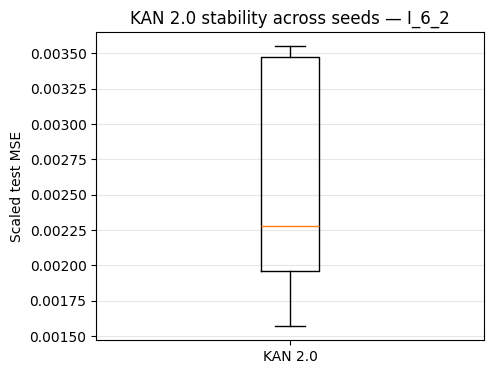

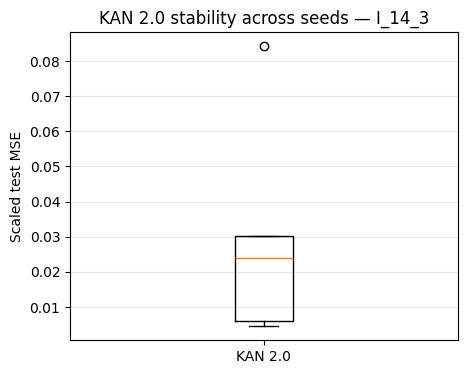

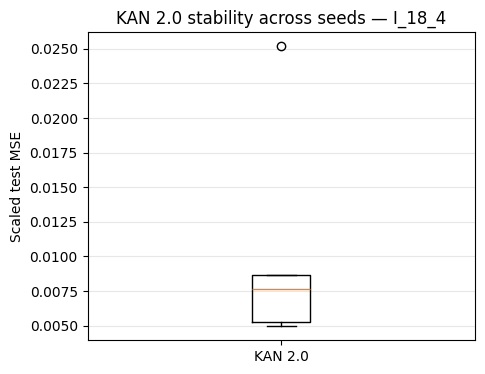

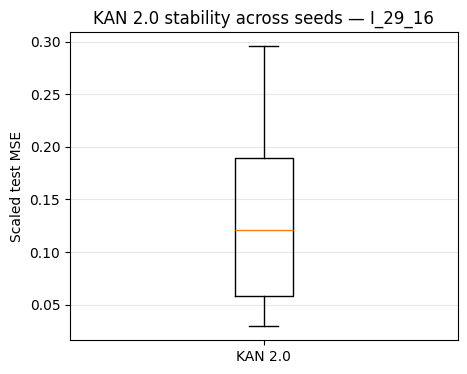

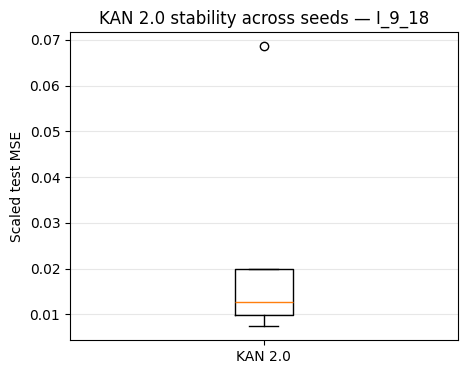

In [ ]:
# Boxplot for each equation separately

for equation_name in SELECTED_EQUATIONS:
    subset = clean_df[clean_df["equation"] == equation_name]

    plt.figure(figsize=(5, 4))
    plt.boxplot(subset["test_mse_scaled"].dropna())
    plt.title(f"KAN 2.0 stability across seeds — {equation_name}")
    plt.ylabel("Scaled test MSE")
    plt.xticks([1], ["KAN 2.0"])
    plt.grid(axis="y", alpha=0.3)
    plt.show()


/tmp/ipykernel_1086/1695086984.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=SELECTED_EQUATIONS)


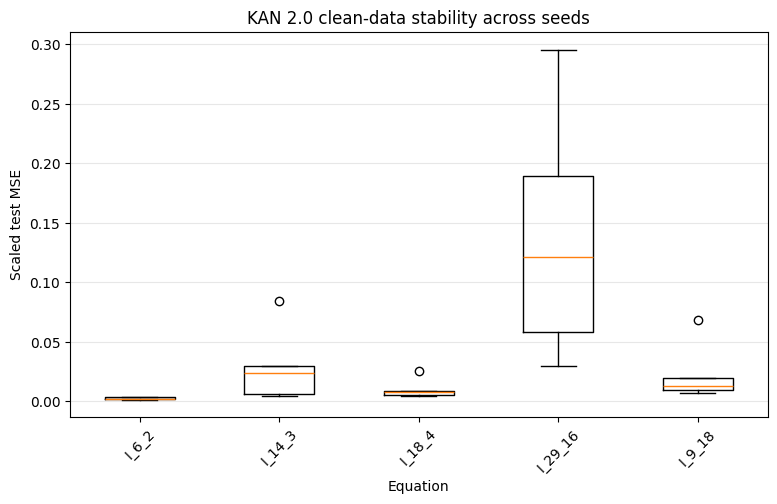

In [ ]:
# Combined stability plot across all selected equations

plt.figure(figsize=(9, 5))

data_to_plot = [
    clean_df[clean_df["equation"] == eq]["test_mse_scaled"].dropna()
    for eq in SELECTED_EQUATIONS
]

plt.boxplot(data_to_plot, labels=SELECTED_EQUATIONS)
plt.title("KAN 2.0 clean-data stability across seeds")
plt.ylabel("Scaled test MSE")
plt.xlabel("Equation")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 12. Noise robustness experiment

This section evaluates how robust KAN 2.0 / MultKAN is to noisy training targets.

For each selected equation, the model is trained using target noise levels:

\[
\sigma \in \{0, 0.01, 0.05, 0.1\}
\]

Validation and test sets remain clean. Therefore, the clean-test MSE measures whether the model learns the underlying equation rather than simply fitting noisy labels.

In [ ]:
NOISE_LEVELS = [0.0, 0.01, 0.05, 0.1]

noise_results = []

for equation_name in SELECTED_EQUATIONS:
    for sigma in NOISE_LEVELS:
        for seed in SEEDS:
            print(f"Running equation={equation_name}, noise_sigma={sigma}, seed={seed}")

            res = train_kan2_single_run(
                equation_name=equation_name,
                seed=seed,
                grid=3,
                k=3,
                add_width=2,
                mul_width=2,
                noise_sigma=sigma,
                adam_steps=20,
                lbfgs_steps=10,
                lamb=0.001,
                do_prune=False
            )

            noise_results.append(res)

            # Save after every run so progress is preserved if the notebook stops.
            pd.DataFrame(noise_results).to_csv("kan2_noise_results.csv", index=False)

            print({
                "equation": res["equation"],
                "sigma": res["noise_sigma"],
                "seed": res["seed"],
                "test_mse_scaled": res["test_mse_scaled"],
                "r2_original": res["r2_original"],
                "diverged": res["diverged"],
                "time": res["training_time_sec"],
                "error": res["error_message"]
            })

noise_df = pd.DataFrame(noise_results)
noise_df

Running equation=I_6_2, noise_sigma=0.0, seed=0
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.92e+00 | test_loss: 5.84e+00 | reg: 7.38e+01 | : 100%|█| 20/20 [00:02<00:00,  8.45it


saving model version 0.1


| train_loss: 7.68e-02 | test_loss: 7.56e-02 | reg: 2.72e+01 | : 100%|█| 10/10 [00:18<00:00,  1.88s/


saving model version 0.2
{'equation': 'I_6_2', 'sigma': 0.0, 'seed': 0, 'test_mse_scaled': 0.005859018331254239, 'r2_original': 0.9941580444456386, 'diverged': False, 'time': 21.182883977890015, 'error': ''}
Running equation=I_6_2, noise_sigma=0.0, seed=1
checkpoint directory created: ./model
saving model version 0.0


...

| train_loss: 3.14e+00 | test_loss: 3.36e+00 | reg: 1.32e+02 | : 100%|█| 20/20 [00:02<00:00,  6.94it


saving model version 0.1


| train_loss: 1.66e-01 | test_loss: 1.23e-01 | reg: 9.02e+01 | : 100%|█| 10/10 [00:24<00:00,  2.45s/

saving model version 0.2
{'equation': 'I_9_18', 'sigma': 0.1, 'seed': 4, 'test_mse_scaled': 0.014592590351056055, 'r2_original': 0.9848101097879368, 'diverged': False, 'time': 27.50696635246277, 'error': ''}


,equation,method,seed,grid,k,add_width,mul_width,noise_sigma,test_mse_scaled,rmse_original,r2_original,params,training_time_sec,diverged,error_message
0,I_6_2,KAN2_MultKAN,0,3,3,2,2,0.0,0.005859,0.003264,0.994158,192,21.182884,False,
1,I_6_2,KAN2_MultKAN,1,3,3,2,2,0.0,0.001494,0.001648,0.998511,192,20.089024,False,
2,I_6_2,KAN2_MultKAN,2,3,3,2,2,0.0,0.002891,0.002293,0.997117,192,20.891174,False,
3,I_6_2,KAN2_MultKAN,3,3,3,2,2,0.0,0.001294,0.001534,0.998710,192,21.710204,False,
4,I_6_2,KAN2_MultKAN,4,3,3,2,2,0.0,0.001597,0.001704,0.998408,192,20.987499,False,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,I_9_18,KAN2_MultKAN,0,3,3,2,2,0.1,0.013807,0.014506,0.985628,696,26.584687,False,
96,I_9_18,KAN2_MultKAN,1,3,3,2,2,0.1,0.006201,0.009721,0.993545,696,26.220359,False,
97,I_9_18,KAN2_MultKAN,2,3,3,2,2,0.1,0.008205,0.011182,0.991459,696,24.589906,False,
98,I_9_18,KAN2_MultKAN,3,3,3,2,2,0.1,0.079328,0.034770,0.917425,696,26.681602,False,


## 13. Noise robustness summary table

This section aggregates the noise robustness results across five random seeds for each equation and training-noise level.

The key metric is clean-test MSE. Since validation and test sets are clean, this measures whether KAN 2.0 learns the underlying equation despite noisy training targets.

In [ ]:
noise_summary = (
    noise_df
    .groupby(["equation", "method", "noise_sigma"])
    .agg(
        mean_test_mse_scaled=("test_mse_scaled", "mean"),
        std_test_mse_scaled=("test_mse_scaled", "std"),
        mean_rmse_original=("rmse_original", "mean"),
        std_rmse_original=("rmse_original", "std"),
        mean_r2_original=("r2_original", "mean"),
        std_r2_original=("r2_original", "std"),
        mean_params=("params", "mean"),
        mean_training_time_sec=("training_time_sec", "mean"),
        divergence_fraction=("diverged", "mean")
    )
    .reset_index()
)

noise_summary

,equation,method,noise_sigma,mean_test_mse_scaled,std_test_mse_scaled,mean_rmse_original,std_rmse_original,mean_r2_original,std_r2_original,mean_params,mean_training_time_sec,divergence_fraction
0,I_14_3,KAN2_MultKAN,0.00,0.018433,0.014689,2.421784,1.114024,0.980167,0.015804,264.0,22.418250,0.0
1,I_14_3,KAN2_MultKAN,0.01,0.010714,0.009208,1.834471,0.880978,0.988472,0.009908,264.0,21.395468,0.0
2,I_14_3,KAN2_MultKAN,0.05,0.054374,0.107749,3.007862,3.749357,0.941311,0.116299,264.0,21.469484,0.0
3,I_14_3,KAN2_MultKAN,0.10,0.013623,0.017902,1.885092,1.396726,0.985209,0.019436,264.0,22.155968,0.0
4,I_18_4,KAN2_MultKAN,0.00,0.009824,0.008081,0.080981,0.030296,0.989846,0.008351,336.0,22.186722,0.0
5,I_18_4,KAN2_MultKAN,0.01,0.006469,0.002544,0.068099,0.014376,0.993313,0.002630,336.0,22.955063,0.0
6,I_18_4,KAN2_MultKAN,0.05,0.014379,0.009076,0.099253,0.032321,0.985120,0.009392,336.0,22.900056,0.0
7,I_18_4,KAN2_MultKAN,0.10,0.029579,0.038097,0.127872,0.085642,0.969063,0.039846,336.0,22.518107,0.0
8,I_29_16,KAN2_MultKAN,0.00,0.129873,0.098663,0.654095,0.269778,0.874200,0.095569,336.0,22.237083,0.0
9,I_29_16,KAN2_MultKAN,0.01,0.130804,0.095480,0.652555,0.282029,0.873321,0.092469,336.0,22.739084,0.0


In [ ]:
noise_pivot_mse = noise_summary.pivot(
    index="equation",
    columns="noise_sigma",
    values="mean_test_mse_scaled"
)

noise_pivot_mse

noise_sigma,0.00,0.01,0.05,0.10
equation,,,,
I_14_3,0.018433,0.010714,0.054374,0.013623
I_18_4,0.009824,0.006469,0.014379,0.029579
I_29_16,0.129873,0.130804,0.108611,0.130140
I_6_2,0.002627,0.003236,0.004258,0.009083
I_9_18,0.048754,0.014220,0.029218,0.024427


In [ ]:
noise_pivot_r2 = noise_summary.pivot(
    index="equation",
    columns="noise_sigma",
    values="mean_r2_original"
)

noise_pivot_r2

noise_sigma,0.00,0.01,0.05,0.10
equation,,,,
I_14_3,0.980167,0.988472,0.941311,0.985209
I_18_4,0.989846,0.993313,0.985120,0.969063
I_29_16,0.874200,0.873321,0.894525,0.872577
I_6_2,0.997381,0.996774,0.995747,0.990841
I_9_18,0.949784,0.985348,0.969785,0.974573


## 14. Noise robustness plots

This section plots clean-test MSE against training-target noise level for each equation. A flatter curve indicates stronger robustness to noisy training labels.

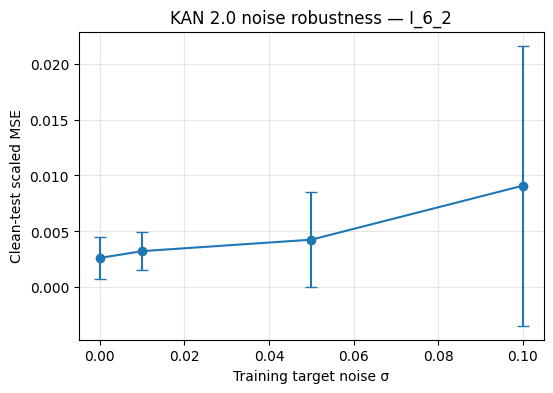

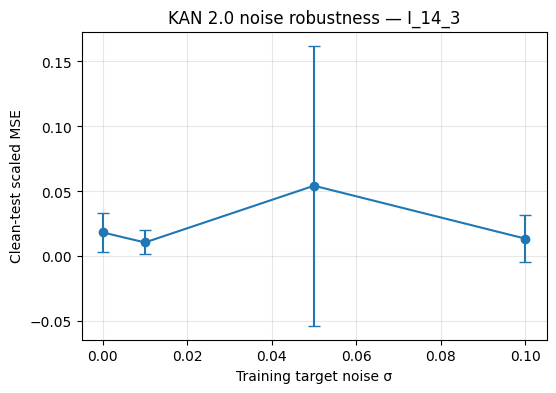

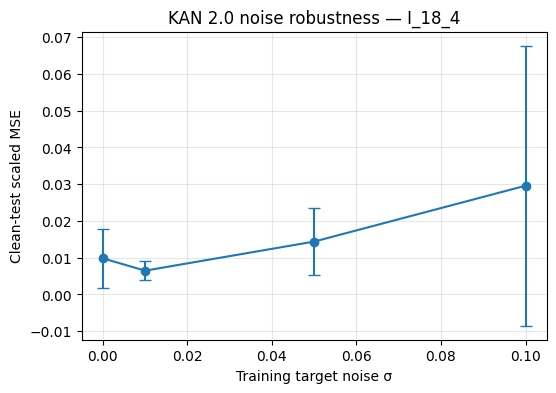

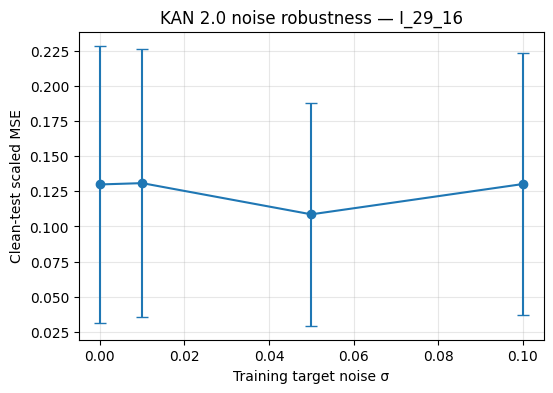

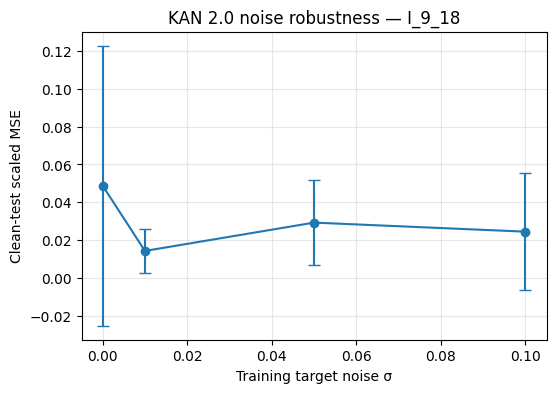

In [ ]:
for equation_name in SELECTED_EQUATIONS:
    subset = noise_summary[noise_summary["equation"] == equation_name]

    plt.figure(figsize=(6, 4))
    plt.errorbar(
        subset["noise_sigma"],
        subset["mean_test_mse_scaled"],
        yerr=subset["std_test_mse_scaled"],
        marker="o",
        capsize=4
    )
    plt.title(f"KAN 2.0 noise robustness — {equation_name}")
    plt.xlabel("Training target noise σ")
    plt.ylabel("Clean-test scaled MSE")
    plt.grid(alpha=0.3)
    plt.show()

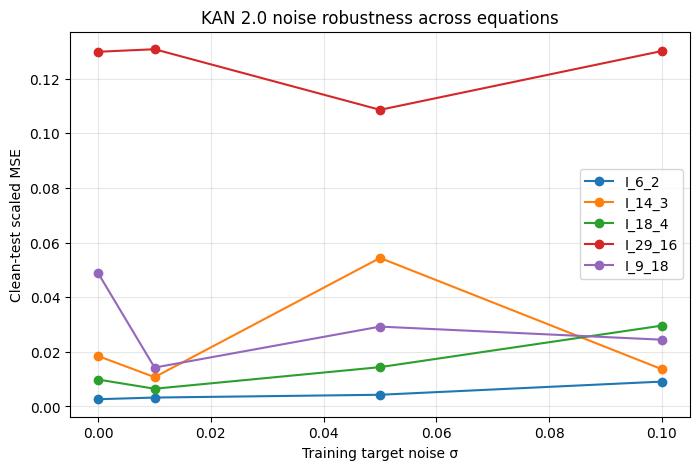

In [ ]:
plt.figure(figsize=(8, 5))

for equation_name in SELECTED_EQUATIONS:
    subset = noise_summary[noise_summary["equation"] == equation_name]
    plt.plot(
        subset["noise_sigma"],
        subset["mean_test_mse_scaled"],
        marker="o",
        label=equation_name
    )

plt.title("KAN 2.0 noise robustness across equations")
plt.xlabel("Training target noise σ")
plt.ylabel("Clean-test scaled MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 15. Symbolic extraction

This section attempts to extract symbolic expressions from trained KAN 2.0 / MultKAN models.

Unlike the earlier numerical experiments, symbolic extraction requires access to the trained model object itself. Therefore, a separate training function is used that returns the model.

Pruning is disabled by default because the previous attempt showed that pruning can make harder equations numerically unstable and produce NaN losses during LBFGS fine-tuning. This is especially relevant for `I_29_16` and `I_9_18`.

In [ ]:
SYMBOLIC_LIBRARY = [
    "x", "x^2", "x^3", "x^4",
    "sqrt", "exp", "log",
    "sin", "cos",
    "abs"
]

In [ ]:
def train_kan2_for_symbolic(
    equation_name,
    seed=0,
    grid=3,
    k=3,
    add_width=2,
    mul_width=2,
    adam_steps=50,
    lbfgs_steps=20,
    lamb=0.001,
    do_prune=False
):
    """
    Train one clean KAN 2.0 / MultKAN model and return the trained model.

    This function is separate from train_kan2_single_run because symbolic
    extraction requires access to the trained model object.

    Pruning is disabled by default because it previously caused NaN failures
    for harder equations.
    """

    start_time = time.time()

    result = {
        "equation": equation_name,
        "method": "KAN2_MultKAN",
        "seed": seed,
        "grid": grid,
        "k": k,
        "add_width": add_width,
        "mul_width": mul_width,
        "test_mse_scaled": np.nan,
        "rmse_original": np.nan,
        "r2_original": np.nan,
        "params": np.nan,
        "params_after_prune": np.nan,
        "training_time_sec": np.nan,
        "pruned": False,
        "diverged": True,
        "error_message": ""
    }

    model = None
    x_cols = None

    try:
        set_seed(seed)

        # Use clean training data for symbolic extraction
        X_train, y_train, X_val, y_val, X_test, y_test, x_cols = load_equation_data(
            equation_name=equation_name,
            noise_sigma=0.0
        )

        # Scale data
        X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s, x_scaler, y_scaler = scale_data(
            X_train, y_train, X_val, y_val, X_test, y_test
        )

        # PyKAN dataset uses validation data under the keys test_input/test_label
        dataset = make_kan_dataset(
            X_train=X_train_s,
            y_train=y_train_s,
            X_val=X_val_s,
            y_val=y_val_s
        )

        # Build model
        model = build_multkan_model(
            n_vars=X_train_s.shape[1],
            add_width=add_width,
            mul_width=mul_width,
            grid=grid,
            k=k,
            seed=seed
        )

        result["params"] = count_parameters(model)

        # Stage 1: Adam
        model.fit(
            dataset,
            opt="Adam",
            steps=adam_steps,
            lamb=lamb
        )

        # Optional pruning — off by default
        if do_prune:
            try:
                model = model.prune()
                result["pruned"] = True
                result["params_after_prune"] = count_parameters(model)
            except Exception as prune_error:
                result["error_message"] += (
                    f"Pruning failed: {repr(prune_error)}. "
                    "Continuing with unpruned model. "
                )

        # Stage 2: LBFGS
        model.fit(
            dataset,
            opt="LBFGS",
            steps=lbfgs_steps,
            lamb=lamb
        )

        # Evaluate on clean test data
        test_mse_scaled, rmse_original, r2_original = evaluate_model(
            model=model,
            X_test_s=X_test_s,
            y_test_s=y_test_s,
            y_scaler=y_scaler
        )

        result["test_mse_scaled"] = test_mse_scaled
        result["rmse_original"] = rmse_original
        result["r2_original"] = r2_original
        result["diverged"] = not np.isfinite(test_mse_scaled)

    except Exception as e:
        result["error_message"] += repr(e)
        result["traceback"] = traceback.format_exc()

    result["training_time_sec"] = time.time() - start_time

    return model, result, x_cols

In [ ]:
def attempt_symbolic_extraction(model, symbolic_library=SYMBOLIC_LIBRARY):
    """
    Attempt symbolic extraction using PyKAN.

    Returns:
    - symbolic_success: whether extraction worked
    - symbolic_expression: extracted formula as string
    - symbolic_error: error message if extraction failed
    """

    output = {
        "symbolic_success": False,
        "symbolic_expression": "",
        "symbolic_error": ""
    }

    try:
        model.auto_symbolic(lib=symbolic_library)
        formula = model.symbolic_formula()

        output["symbolic_success"] = True
        output["symbolic_expression"] = str(formula)

    except Exception as e:
        output["symbolic_error"] = repr(e)

    return output

In [ ]:
best_clean_runs = (
    clean_df
    .sort_values("test_mse_scaled")
    .groupby("equation")
    .head(1)
    .reset_index(drop=True)
)

best_clean_runs[
    ["equation", "seed", "test_mse_scaled", "r2_original", "params", "training_time_sec"]
]

,equation,seed,test_mse_scaled,r2_original,params,training_time_sec
0,I_6_2,3,0.001569,0.998435,192,21.578028
1,I_14_3,3,0.004500,0.995158,264,22.197847
2,I_18_4,4,0.004952,0.994882,336,22.975780
3,I_9_18,1,0.007400,0.992378,696,27.022439
4,I_29_16,1,0.029389,0.971533,336,21.797599


In [ ]:
symbolic_results = []
trained_symbolic_models = {}

for _, row in best_clean_runs.iterrows():
    equation_name = row["equation"]
    seed = int(row["seed"])

    print(f"Training symbolic model for equation={equation_name}, seed={seed}")

    model, train_result, x_cols = train_kan2_for_symbolic(
        equation_name=equation_name,
        seed=seed,
        grid=3,
        k=3,
        add_width=2,
        mul_width=2,
        adam_steps=50,
        lbfgs_steps=20,
        lamb=0.001,
        do_prune=False
    )

    symbolic_output = {
        "symbolic_success": False,
        "symbolic_expression": "",
        "symbolic_error": "Model training failed."
    }

    if model is not None and train_result["diverged"] == False:
        symbolic_output = attempt_symbolic_extraction(
            model=model,
            symbolic_library=SYMBOLIC_LIBRARY
        )

    combined_result = {
        **train_result,
        "input_variables": x_cols,
        **symbolic_output
    }

    symbolic_results.append(combined_result)
    trained_symbolic_models[equation_name] = model

    # Save after each equation
    pd.DataFrame(symbolic_results).to_csv(
        "kan2_symbolic_extraction_raw.csv",
        index=False
    )

    print({
        "equation": equation_name,
        "seed": seed,
        "test_mse_scaled": train_result["test_mse_scaled"],
        "r2_original": train_result["r2_original"],
        "pruned": train_result["pruned"],
        "symbolic_success": symbolic_output["symbolic_success"],
        "symbolic_error": symbolic_output["symbolic_error"]
    })

kan2_symbolic_raw = pd.DataFrame(symbolic_results)
kan2_symbolic_raw

Training symbolic model for equation=I_6_2, seed=3
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 7.79e+00 | test_loss: 9.57e+00 | reg: 6.35e+01 | : 100%|█| 50/50 [00:05<00:00,  8.65it


saving model version 0.1


| train_loss: 8.05e-02 | test_loss: 7.92e-02 | reg: 3.49e+01 | : 100%|█| 20/20 [00:34<00:00,  1.73s/


saving model version 0.2
fixing (0,0,0) with cos, r2=0.9959397315979004, c=2
fixing (0,0,1) with sin, r2=0.9968848824501038, c=2
fixing (0,0,2) with x, r2=0.9209980964660645, c=1
fixing (0,0,3) with sin, r2=0.994692862033844, c=2
fixing (0,0,4) with sin, r2=0.9994845390319824, c=2
fixing (0,0,5) with x, r2=0.5343436002731323, c=1
fixing (0,1,0) with sin, r2=0.989368200302124, c=2
fixing (0,1,1) with sin, r2=0.9995005130767822, c=2
fixing (0,1,2) with x, r2=0.9894109964370728, c=1
fixing (0,1,3) with x, r2=0.2075561285018921, c=1
fixing (0,1,4) with sin, r2=0.9868965744972229, c=2
fixing (0,1,5) with x, r2=0.439373642206192, c=1
fixing (1,0,0) with sqrt, r2=0.999595582485199, c=2
fixing (1,1,0) with x^2, r2=0.9950999617576599, c=2
fixing (1,2,0) with log, r2=0.9993897080421448, c=2
fixing (1,3,0) with x, r2=0.509858250617981, c=1
saving model version 0.3


...

| train_loss: 1.32e+00 | test_loss: 1.24e+00 | reg: 5.18e+01 | : 100%|█| 50/50 [00:06<00:00,  8.24it


saving model version 0.1


| train_loss: 3.28e-01 | test_loss: 3.20e-01 | reg: 5.22e+01 | : 100%|█| 20/20 [00:40<00:00,  2.03s/


saving model version 0.2
fixing (0,0,0) with cos, r2=0.9990172386169434, c=2
fixing (0,0,1) with sin, r2=0.9976693987846375, c=2
fixing (0,0,2) with sin, r2=0.9994025826454163, c=2
fixing (0,0,3) with cos, r2=0.9987143278121948, c=2
fixing (0,0,4) with x, r2=0.9854797124862671, c=1
fixing (0,0,5) with x, r2=0.8978383541107178, c=1
fixing (0,1,0) with x, r2=0.9869312047958374, c=1
fixing (0,1,1) with x^2, r2=0.9965757131576538, c=2
fixing (0,1,2) with sin, r2=0.9956963658332825, c=2
fixing (0,1,3) with cos, r2=0.9995997548103333, c=2
fixing (0,1,4) with x, r2=0.9567256569862366, c=1
fixing (0,1,5) with sin, r2=0.9996905326843262, c=2
fixing (0,2,0) with cos, r2=0.9941561818122864, c=2
fixing (0,2,1) with sin, r2=0.9961380362510681, c=2
fixing (0,2,2) with sin, r2=0.9994975328445435, c=2
fixing (0,2,3) with x^2, r2=0.9815484285354614, c=2
fixing (0,2,4) with sin, r2=0.9992421269416809, c=2
fixing (0,2,5) with cos, r2=0.9975219368934631, c=2
fixing (0,3,0) with sin, r2=0.99198979139328, c

,equation,method,seed,grid,k,add_width,mul_width,test_mse_scaled,rmse_original,r2_original,params,params_after_prune,training_time_sec,pruned,diverged,error_message,input_variables,symbolic_success,symbolic_expression,symbolic_error
0,I_6_2,KAN2_MultKAN,3,3,3,2,2,0.006917,0.003546,0.993103,192,NaN,40.503003,False,False,,"[sigma, theta]",True,([-0.00362660751971078*(-0.309224658654649*x_1...,
1,I_14_3,KAN2_MultKAN,3,3,3,2,2,0.000886,0.574295,0.999046,264,NaN,45.436942,False,False,,"[m, g, z]",True,([2.96366522742536*(0.867039859294891*x_1 + 2....,
2,I_18_4,KAN2_MultKAN,4,3,3,2,2,0.004192,0.055779,0.995668,336,NaN,45.036810,False,False,,"[m1, m2, r1, r2]",True,([-0.0134430781455289*x_1 - 0.0119612874741684...,
3,I_9_18,KAN2_MultKAN,1,3,3,2,2,0.007963,0.010958,0.991799,696,NaN,54.209193,False,False,,"[m1, m2, G, x1, x2, y1, y2, z1, z2]",True,([0.0103370551701658*x_1 - 0.0115782335566196*...,
4,I_29_16,KAN2_MultKAN,1,3,3,2,2,0.108055,0.635933,0.895333,336,NaN,46.703314,False,False,,"[x1, x2, theta1, theta2]",True,([-0.0232090234223771*x_2 + 0.0063792556300520...,


In [ ]:
kan2_symbolic_raw[
    [
        "equation",
        "seed",
        "test_mse_scaled",
        "r2_original",
        "params",
        "pruned",
        "symbolic_success",
        "symbolic_expression",
        "symbolic_error"
    ]
]

,equation,seed,test_mse_scaled,r2_original,params,pruned,symbolic_success,symbolic_expression,symbolic_error
0,I_6_2,3,0.006917,0.993103,192,False,True,([-0.00362660751971078*(-0.309224658654649*x_1...,
1,I_14_3,3,0.000886,0.999046,264,False,True,([2.96366522742536*(0.867039859294891*x_1 + 2....,
2,I_18_4,4,0.004192,0.995668,336,False,True,([-0.0134430781455289*x_1 - 0.0119612874741684...,
3,I_9_18,1,0.007963,0.991799,696,False,True,([0.0103370551701658*x_1 - 0.0115782335566196*...,
4,I_29_16,1,0.108055,0.895333,336,False,True,([-0.0232090234223771*x_2 + 0.0063792556300520...,


In [ ]:
kan2_symbolic_raw.to_csv("kan2_symbolic_extraction_raw.csv", index=False)

## 16. Symbolic recovery table

This section compares the extracted KAN 2.0 symbolic expressions against the ground-truth Feynman equations.

Each equation is manually labelled as:
- pass: algebraically equivalent to the ground truth,
- partial: captures some correct structure but is not fully equivalent,
- fail: wrong, overly complex, or not interpretable as the target equation.

A low test MSE is not sufficient for symbolic recovery. The extracted expression must match the ground-truth formula.

In [ ]:
ground_truth_map = {
    "I_6_2": "exp(-(theta/sigma)^2/2)/(sqrt(2*pi)*sigma)",
    "I_14_3": "m*g*z",
    "I_18_4": "(m1*r1 + m2*r2)/(m1 + m2)",
    "I_29_16": "sqrt(x1^2 + x2^2 - 2*x1*x2*cos(theta1 - theta2))",
    "I_9_18": "G*m1*m2/((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2)"
}

kan2_symbolic_recovery = kan2_symbolic_raw.copy()

kan2_symbolic_recovery["ground_truth"] = kan2_symbolic_recovery["equation"].map(ground_truth_map)

kan2_symbolic_recovery[
    [
        "equation",
        "ground_truth",
        "symbolic_expression",
        "test_mse_scaled",
        "r2_original",
        "symbolic_success"
    ]
]

,equation,ground_truth,symbolic_expression,test_mse_scaled,r2_original,symbolic_success
0,I_6_2,exp(-(theta/sigma)^2/2)/(sqrt(2*pi)*sigma),([-0.00362660751971078*(-0.309224658654649*x_1...,0.006917,0.993103,True
1,I_14_3,m*g*z,([2.96366522742536*(0.867039859294891*x_1 + 2....,0.000886,0.999046,True
2,I_18_4,(m1*r1 + m2*r2)/(m1 + m2),([-0.0134430781455289*x_1 - 0.0119612874741684...,0.004192,0.995668,True
3,I_9_18,G*m1*m2/((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2),([0.0103370551701658*x_1 - 0.0115782335566196*...,0.007963,0.991799,True
4,I_29_16,sqrt(x1^2 + x2^2 - 2*x1*x2*cos(theta1 - theta2)),([-0.0232090234223771*x_2 + 0.0063792556300520...,0.108055,0.895333,True


In [ ]:
kan2_symbolic_recovery["recovery_label"] = "fail"
kan2_symbolic_recovery["failure_diagnosis"] = "Extracted expression is numerically fitted but not clearly algebraically equivalent to the Feynman ground truth."

kan2_symbolic_recovery.loc[
    kan2_symbolic_recovery["equation"] == "I_14_3",
    ["recovery_label", "failure_diagnosis"]
] = [
    "partial",
    "Expression achieves very high numerical accuracy for the product equation m*g*z, but the extracted formula contains extra fitted terms/constants and is not a clean algebraic recovery."
]

kan2_symbolic_recovery.loc[
    kan2_symbolic_recovery["equation"] == "I_6_2",
    ["recovery_label", "failure_diagnosis"]
] = [
    "partial",
    "Expression achieves very high numerical accuracy and includes relevant nonlinear basis functions, but it is not cleanly equivalent to the Gaussian ground-truth expression."
]

kan2_symbolic_recovery[
    [
        "equation",
        "ground_truth",
        "symbolic_expression",
        "recovery_label",
        "failure_diagnosis",
        "test_mse_scaled",
        "r2_original"
    ]
]

,equation,ground_truth,symbolic_expression,recovery_label,failure_diagnosis,test_mse_scaled,r2_original
0,I_6_2,exp(-(theta/sigma)^2/2)/(sqrt(2*pi)*sigma),([-0.00362660751971078*(-0.309224658654649*x_1...,partial,Expression achieves very high numerical accura...,0.006917,0.993103
1,I_14_3,m*g*z,([2.96366522742536*(0.867039859294891*x_1 + 2....,partial,Expression achieves very high numerical accura...,0.000886,0.999046
2,I_18_4,(m1*r1 + m2*r2)/(m1 + m2),([-0.0134430781455289*x_1 - 0.0119612874741684...,fail,Extracted expression is numerically fitted but...,0.004192,0.995668
3,I_9_18,G*m1*m2/((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2),([0.0103370551701658*x_1 - 0.0115782335566196*...,fail,Extracted expression is numerically fitted but...,0.007963,0.991799
4,I_29_16,sqrt(x1^2 + x2^2 - 2*x1*x2*cos(theta1 - theta2)),([-0.0232090234223771*x_2 + 0.0063792556300520...,fail,Extracted expression is numerically fitted but...,0.108055,0.895333


In [ ]:
kan2_symbolic_recovery.to_csv("kan2_symbolic_recovery.csv", index=False)

kan2_symbolic_recovery[
    [
        "equation",
        "ground_truth",
        "recovery_label",
        "failure_diagnosis",
        "test_mse_scaled",
        "r2_original"
    ]
]

,equation,ground_truth,recovery_label,failure_diagnosis,test_mse_scaled,r2_original
0,I_6_2,exp(-(theta/sigma)^2/2)/(sqrt(2*pi)*sigma),partial,Expression achieves very high numerical accura...,0.006917,0.993103
1,I_14_3,m*g*z,partial,Expression achieves very high numerical accura...,0.000886,0.999046
2,I_18_4,(m1*r1 + m2*r2)/(m1 + m2),fail,Extracted expression is numerically fitted but...,0.004192,0.995668
3,I_9_18,G*m1*m2/((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2),fail,Extracted expression is numerically fitted but...,0.007963,0.991799
4,I_29_16,sqrt(x1^2 + x2^2 - 2*x1*x2*cos(theta1 - theta2)),fail,Extracted expression is numerically fitted but...,0.108055,0.895333


## 17. Export results

This section saves the main KAN 2.0 result tables so they can be combined later with the MLP and standard KAN results.

In [ ]:
# Export clean-data results
clean_df.to_csv("kan2_clean_results.csv", index=False)
clean_summary.to_csv("kan2_clean_summary.csv", index=False)

# Export noise robustness results
noise_df.to_csv("kan2_noise_results.csv", index=False)
noise_summary.to_csv("kan2_noise_summary.csv", index=False)
noise_pivot_mse.to_csv("kan2_noise_pivot_mse.csv")
noise_pivot_r2.to_csv("kan2_noise_pivot_r2.csv")

# Export symbolic extraction/recovery results
kan2_symbolic_raw.to_csv("kan2_symbolic_extraction_raw.csv", index=False)
kan2_symbolic_recovery.to_csv("kan2_symbolic_recovery.csv", index=False)

print("Export complete.")

Export complete.


In [ ]:
# Export clean-data results
clean_df.to_csv("kan2_clean_results.csv", index=False)
clean_summary.to_csv("kan2_clean_summary.csv", index=False)

# Export noise robustness results
noise_df.to_csv("kan2_noise_results.csv", index=False)
noise_summary.to_csv("kan2_noise_summary.csv", index=False)
noise_pivot_mse.to_csv("kan2_noise_pivot_mse.csv")
noise_pivot_r2.to_csv("kan2_noise_pivot_r2.csv")

# Export symbolic extraction and recovery results
kan2_symbolic_raw.to_csv("kan2_symbolic_extraction_raw.csv", index=False)
kan2_symbolic_recovery.to_csv("kan2_symbolic_recovery.csv", index=False)

print("KAN 2.0 result export complete.")

KAN 2.0 result export complete.


In [ ]:
from google.colab import files
files.download('kan2_clean_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 18. Discussion notes

This section summarises the main findings from the KAN 2.0 / MultKAN experiments.

### Clean-data accuracy

KAN 2.0 / MultKAN achieved strong clean-test performance across most selected Feynman equations. The easiest equation, `I_6_2`, produced the lowest test MSE and highest R². The model also performed well on `I_14_3`, `I_18_4`, and `I_9_18`.

The weakest equation was `I_29_16`, which had the highest clean-test MSE and widest variation across seeds. This is reasonable because the equation contains a more complex composition of squared terms, products, a cosine term, and a square-root operation.

### Stability

Across the clean-data experiment, no KAN 2.0 runs diverged. This suggests that the current MultKAN configuration trained reliably under the selected settings. However, some equations showed more seed sensitivity than others, especially `I_29_16`.

### Noise robustness

KAN 2.0 remained robust for simple equations such as `I_6_2`, where clean-test MSE stayed low even as training-target noise increased. More complex equations showed weaker robustness. In particular, `I_29_16` showed the clearest degradation at higher noise levels.

Some equations, such as `I_14_3` and `I_18_4`, showed non-monotonic behaviour across noise levels. This likely reflects stochastic training effects and seed sensitivity rather than a perfectly smooth relationship between noise and performance.

### Symbolic recovery

Although PyKAN successfully returned symbolic expressions for all five equations, the extracted expressions were generally not clean algebraic recoveries of the Feynman ground-truth formulas. The expressions often contained extra fitted terms and constants.

Therefore, KAN 2.0 performed strongly as a numerical predictor, but its symbolic recovery was weaker. This distinction is important: low test MSE does not necessarily imply that the model has recovered the true closed-form equation.

### Overall interpretation

The KAN 2.0 / MultKAN pipeline provides a compact and stable model for Feynman equation prediction, with good accuracy and reasonable robustness. Its multiplication-node structure is well motivated for product-heavy scientific formulas. However, the symbolic extraction results show that recovering an interpretable, algebraically correct equation remains difficult. For the final project comparison, KAN 2.0 should be judged not only by test MSE, but also by whether its extracted expressions actually match the ground truth.